# MLP Classification on the Max Displacement Dataset

This notebook is written as a guided walkthrough for first-time learners, using `inclass_examples/data/scalar/param_disp_dataset.csv` to solve a binary classification task. You will convert a continuous structural response (`max_disp`) into a class label with a configurable threshold, then train a baseline classifier and a small MLP and compare how they behave. The goal is not only to run code, but to build an interpretation habit: each section explains what a result means and how you should read it before moving forward.

Learning goals are embedded directly in the flow: by the end, you should be able to inspect tabular data quality, derive a valid target column, reason about class balance, run PCA and t-SNE for geometric intuition, split data without leakage, standardize features correctly, train classification models with early stopping, and interpret confusion matrices, ROC curves, and class-wise metrics in plain language.


## 1. Imports + Reproducibility Seed

Before touching the dataset, we set up the environment so your notebook behaves predictably. Reproducibility is especially important in machine learning because optimization and sampling procedures can introduce randomness. If you were to run the same notebook with different random seeds, likely you'll get slightly different metrics, and this can often be misinterpreted as a coding error. Setting a fixed seed does not make a model “perfectly deterministic” in every hardware setup, but it greatly improves stability for comparison.

You will also import the exact toolchain used in this notebook: `pandas` for tabular data, `scikit-learn` for preprocessing and evaluation utilities, `matplotlib/seaborn` for visualization, and `keras` for the neural network model.


In [1]:

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
print(f"Seed fixed to {SEED} for Python, NumPy, and TensorFlow.")


Seed fixed to 42 for Python, NumPy, and TensorFlow.


## 2. Load Dataset + Define the Classification Target

The raw CSV stores `max_disp` as a continuous value. For classification, we need discrete labels, so we define a threshold rule as:

`target_class = max_disp > THRESHOLD`

The threshold is intentionally a variable so you can experiment later. A threshold near the center of the target distribution typically gives balanced classes, while extreme thresholds can create severe class imbalance. That imbalance affects how useful metrics like accuracy are, so we will always inspect class counts right after target construction.

This cell also performs a practical path check so the notebook works whether your kernel starts from the repo root or from the notebook directory.


In [2]:
THRESHOLD = 10.0
CSV_PATH = Path("../data/scalar/local_features_dataset.csv")

df = pd.read_csv(CSV_PATH)
target_col = "max_disp"

if target_col not in df.columns:
    raise ValueError(f"The dataset must contain a {target_col} column.")

feature_cols = [c for c in df.columns if c.startswith("x_")]
if not feature_cols:
    raise ValueError("No feature columns found. Expected columns named like x_0, x_1, ..., x_27.")

df["target_class"] = (df[target_col] > THRESHOLD).astype(int)
X = df[feature_cols].copy()
y = df["target_class"].copy()

print(f"Loaded file: {CSV_PATH.resolve()}")
print(f"Rows: {len(df):,} | Feature columns: {len(feature_cols)}")
print(f"Classification threshold: {target_col} > {THRESHOLD}")
print("Class counts (0 = at/below threshold, 1 = above threshold):")
print(y.value_counts())
print("First 5 rows:")
display(df.head())


Loaded file: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\data\scalar\local_features_dataset.csv
Rows: 10,000 | Feature columns: 28
Classification threshold: max_disp > 10.0
Class counts (0 = at/below threshold, 1 = above threshold):
target_class
0    5186
1    4814
Name: count, dtype: int64
First 5 rows:


,index,x_00,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,...,x_20,x_21,x_22,x_23,x_24,x_25,x_26,x_27,max_disp,target_class
0,0,0.139427,-0.474989,-0.281362,0.005355,-0.473464,-0.301162,0.149884,0.044941,-0.279559,...,-0.403284,-0.276789,0.236471,0.176699,0.392180,-0.413061,-0.078078,-0.470203,12.004013,1
1,1,0.347494,0.103726,0.361707,0.077352,0.204572,-0.454176,-0.272102,-0.210612,-0.420208,...,0.109131,0.229732,0.036228,0.473116,-0.121466,0.052041,0.329405,0.118520,2.692905,0
2,2,-0.328861,0.229127,-0.270952,-0.467900,-0.184547,-0.232259,-0.289017,0.442910,0.376368,...,0.397823,-0.120545,0.489523,0.140000,0.056950,0.184614,0.342852,0.276000,7.544037,0
3,3,-0.100599,-0.280679,-0.436472,-0.118381,0.496121,0.029114,0.471078,0.360780,-0.488519,...,-0.236611,0.009526,-0.409091,-0.452884,-0.390351,0.127446,0.292079,-0.077840,13.496088,1
4,4,0.000586,-0.321348,0.278626,0.030354,-0.499428,-0.175844,-0.480523,0.429099,0.378722,...,-0.371609,0.370519,-0.201555,0.138949,0.108970,-0.347161,0.262511,0.039379,8.338048,0


## 3. Data Quality Check

A fast quality check prevents subtle failures later in the pipeline. Here we verify missing values, duplicate rows, and label consistency. In beginner workflows, skipping this stage is a common source of confusion because model performance issues can come from data defects rather than model design.

When you read this output, focus on three questions. First, are there missing values that could break model fitting? Second, are there duplicate rows that might overstate performance? Third, is the class ratio reasonable for the metrics you intend to use? If one class is very rare, accuracy alone is not a trustworthy summary.


In [3]:

missing_counts = df.isna().sum()
missing_total = int(missing_counts.sum())
duplicate_rows = int(df.duplicated().sum())
class_ratio = y.value_counts(normalize=True).sort_index()

print(f"Total missing values across all columns: {missing_total}")
if missing_total > 0:
    display(missing_counts[missing_counts > 0].to_frame("missing_count"))
else:
    print("No missing values detected.")

print(f"Duplicate rows: {duplicate_rows}")
print()
print("Class proportion (0, 1):")
print((class_ratio * 100).round(2).astype(str) + "%")


Total missing values across all columns: 0
No missing values detected.
Duplicate rows: 0

Class proportion (0, 1):
target_class
0    51.86%
1    48.14%
Name: proportion, dtype: object



## 4. Exploratory Data Analysis (EDA)

In this step you build intuition before training anything. Start with the raw target distribution (`max_disp`) and verify where your threshold sits.

You should not expect one plot to “prove” model quality. Instead, treat EDA as a map: where is the target concentrated and how balanced are classes.


C:\Users\Ozguc\AppData\Local\Temp\ipykernel_13588\3048572941.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=["#264653", "#f4a261"], ax=axes[1])


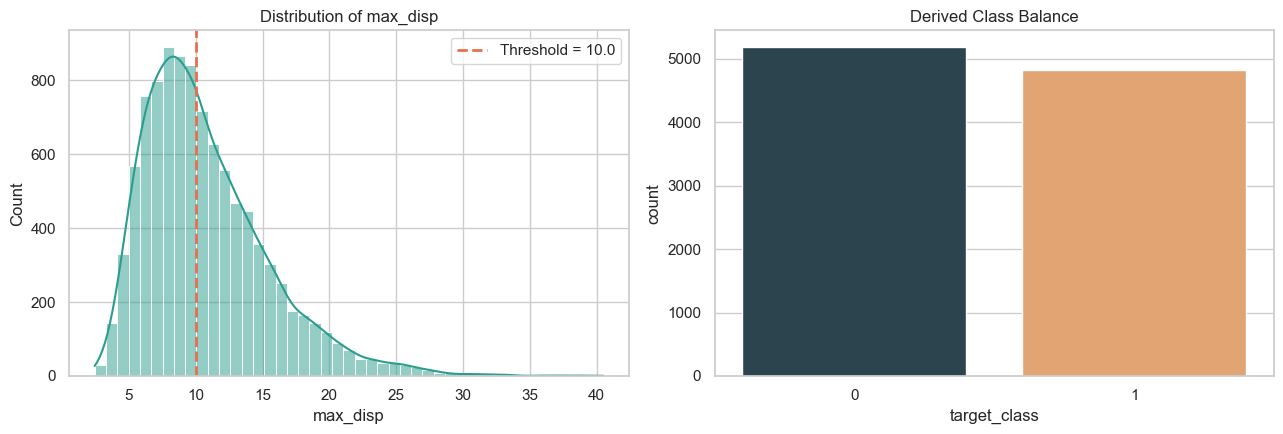

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df[target_col], bins=45, kde=True, color="#2a9d8f", ax=axes[0])
axes[0].axvline(THRESHOLD, color="#e76f51", linestyle="--", linewidth=2, label=f"Threshold = {THRESHOLD}")
axes[0].set_title(f"Distribution of {target_col}")
axes[0].set_xlabel(target_col)
axes[0].legend()

sns.countplot(x=y, palette=["#264653", "#f4a261"], ax=axes[1])
axes[1].set_title("Derived Class Balance")
axes[1].set_xlabel("target_class")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

corr_with_target = (
    df[feature_cols + [target_col]]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=np.abs, ascending=False)
)



### PCA + t-SNE Projection (Structure in Feature Space)

Now you project the 28-dimensional feature space into 2 dimensions with two different methods. PCA is linear and tells you how much variance each principal axis captures. t-SNE is nonlinear and focuses on local neighborhoods, often revealing clusters that PCA can miss. These methods are for understanding geometry, not for direct performance measurement.

For PCA, read the explained variance ratio as “how much of total feature variation this axis summarizes.” For example, if PC1 is 0.20, then PC1 alone captures 20% of variation. If PC1+PC2 is 0.35, then your 2D PCA view preserves about 35% of the original variability. Loadings tell you which original features contribute most strongly to each principal component direction.

For t-SNE, avoid over-interpreting global distances. Separation in t-SNE can be informative, but axis values themselves have no direct physical meaning. To keep runtime demo-friendly, we subsample before t-SNE.

References for deeper reading: [scikit-learn PCA User Guide](https://scikit-learn.org/stable/modules/decomposition.html#pca), [scikit-learn t-SNE User Guide](https://scikit-learn.org/stable/modules/manifold.html#t-sne), [Distill: How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/).


PCA explained variance ratio -> PC1: 0.0392, PC2: 0.0388
PCA cumulative explained variance (PC1 + PC2): 0.0780


c:\Users\Ozguc\.conda\envs\cmdo-ml\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


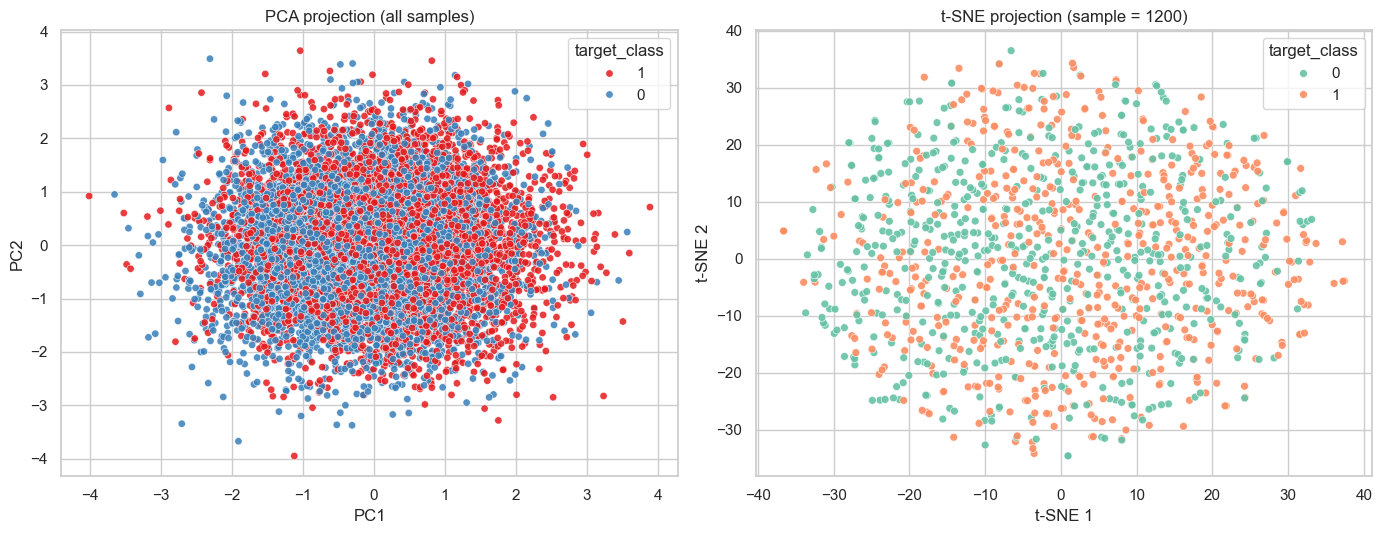

In [5]:

# Standardize only for visualization geometry; this is not the training scaler yet.
X_scaled_for_eda = StandardScaler().fit_transform(X)

# ----- PCA -----
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled_for_eda)

evr = pca.explained_variance_ratio_
print(f"PCA explained variance ratio -> PC1: {evr[0]:.4f}, PC2: {evr[1]:.4f}")
print(f"PCA cumulative explained variance (PC1 + PC2): {evr.sum():.4f}")

# ----- t-SNE (sampled for speed) -----
tsne_sample_size = min(1200, len(X_scaled_for_eda))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_scaled_for_eda), size=tsne_sample_size, replace=False)
X_tsne_input = X_scaled_for_eda[sample_idx]
y_tsne = y.iloc[sample_idx].reset_index(drop=True)

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
).fit_transform(X_tsne_input)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y.astype(str),
    palette="Set1",
    s=28,
    alpha=0.85,
    ax=axes[0],
)
axes[0].set_title("PCA projection (all samples)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title="target_class")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y_tsne.astype(str),
    palette="Set2",
    s=32,
    alpha=0.9,
    ax=axes[1],
)
axes[1].set_title(f"t-SNE projection (sample = {tsne_sample_size})")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(title="target_class")

plt.tight_layout()
plt.show()



## 5. Train/Validation/Test Split

We split first, before fitting any preprocessing transforms, so the validation and test sets stay truly unseen. This is the foundation of honest evaluation. In classification, you should usually stratify so each split keeps roughly the same class ratio; otherwise, a random split can accidentally distort class balance and make metrics unstable.

The two-step split below gives approximately 70% train, 15% validation, and 15% test. Validation is used during model development (for early stopping and model choices), while test is reserved for the final one-time performance estimate.

References for stronger foundations: [scikit-learn: train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), [scikit-learn: StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), [Data leakage overview (scikit-learn common pitfalls)](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).


In [6]:

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print("Split sizes:")
print(f"Train: {X_train_raw.shape[0]} samples")
print(f"Val:   {X_val_raw.shape[0]} samples")
print(f"Test:  {X_test_raw.shape[0]} samples")

print()
print("Class balance check (proportion of class 1):")
print(f"Train: {y_train.mean():.3f}")
print(f"Val:   {y_val.mean():.3f}")
print(f"Test:  {y_test.mean():.3f}")


Split sizes:
Train: 7000 samples
Val:   1500 samples
Test:  1500 samples

Class balance check (proportion of class 1):
Train: 0.481
Val:   0.481
Test:  0.481



## 6. Leakage-Safe Preprocessing (Standardization)

Neural networks and linear models train more reliably when feature scales are comparable. Standardization rescales each feature to zero mean and unit variance, but this transform must be fitted on training data only. If you fit the scaler on all data, information from validation/test leaks into training and inflates performance estimates.

Read the quick diagnostics at the end of this cell as a sanity check. You should see train-set scaled means close to 0 and standard deviations close to 1 for each feature.


In [7]:

scaler = StandardScaler()

# Fit only on training inputs to avoid leakage.
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print("Scaled arrays ready.")
print("Train scaled mean (first 5 features):", np.round(X_train.mean(axis=0)[:5], 3))
print("Train scaled std  (first 5 features):", np.round(X_train.std(axis=0)[:5], 3))


Scaled arrays ready.
Train scaled mean (first 5 features): [0. 0. 0. 0. 0.]
Train scaled std  (first 5 features): [1. 1. 1. 1. 1.]



## 7. Baseline Model (Logistic Regression)

A baseline answers one critical question: is the neural network actually adding value? Logistic regression is a strong, interpretable baseline for binary classification on tabular data. If your MLP barely beats it, your dataset might be close to linearly separable or your neural network setup may need adjustment.

Use the validation split here because we are still in development mode. Test data remains untouched until the final evaluation section.


In [8]:

baseline = LogisticRegression(max_iter=1000, random_state=SEED)
baseline.fit(X_train, y_train)

baseline_val_pred = baseline.predict(X_val)

print("Validation metrics - Logistic Regression baseline")
print(f"Accuracy : {accuracy_score(y_val, baseline_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, baseline_val_pred):.4f}")
print(f"Recall   : {recall_score(y_val, baseline_val_pred):.4f}")
print(f"F1-score : {f1_score(y_val, baseline_val_pred):.4f}")


Validation metrics - Logistic Regression baseline
Accuracy : 0.7787
Precision: 0.7794
Recall   : 0.7535
F1-score : 0.7662



## 8. Neural Network Model (MLP)

Now we train a small multilayer perceptron with two hidden layers. For beginners, the aim is to understand the training loop and validation behavior, not to maximize benchmark numbers. We use `binary_crossentropy` because this is a binary target and add metrics (`accuracy`, `precision`, `recall`, `AUC`) so you can inspect trade-offs.

Early stopping is enabled to prevent over-training once validation loss stops improving. This is a practical regularization pattern you will use often in real workflows.

References for model mechanics: [Keras Sequential API](https://keras.io/guides/sequential_model/), [Keras EarlyStopping](https://keras.io/api/callbacks/early_stopping/), [Adam optimizer paper](https://arxiv.org/abs/1412.6980).


In [9]:

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=16,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=512,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1,
)

print(f"Training finished after {len(history.history['loss'])} epochs.")


Epoch 1/512
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5082 - auc: 0.5286 - loss: 0.7028 - precision: 0.4925 - recall: 0.7903 - val_accuracy: 0.5993 - val_auc: 0.6584 - val_loss: 0.6684 - val_precision: 0.5648 - val_recall: 0.7299
Epoch 2/512
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6136 - auc: 0.6706 - loss: 0.6623 - precision: 0.5794 - recall: 0.7137 - val_accuracy: 0.6813 - val_auc: 0.7514 - val_loss: 0.6319 - val_precision: 0.6449 - val_recall: 0.7521
Epoch 3/512
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6836 - auc: 0.7570 - loss: 0.6228 - precision: 0.6537 - recall: 0.7265 - val_accuracy: 0.7133 - val_auc: 0.7975 - val_loss: 0.5882 - val_precision: 0.6867 - val_recall: 0.7438
Epoch 4/512
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7240 - auc: 0.8029 - loss: 0.5761 - precision: 0.7027 - recall: 0.7377 - val_accuracy: 0.7407 - val_auc: 0.8252 - val_loss: 0.5425 - val_precision: 0.7253 - val_recall: 0.7424
Epoch 5/512
110/110 ━━━━━━━━


## 9. Training Curves

Training curves help you diagnose model behavior beyond a single metric value. If training loss drops while validation loss rises, you are likely overfitting. If both losses stay high and flat, the model may be underfitting or learning too slowly.

When reading these plots, focus on trend shape rather than one noisy epoch. The ideal pattern is a smooth reduction in both training and validation loss, followed by a plateau where early stopping ends training.


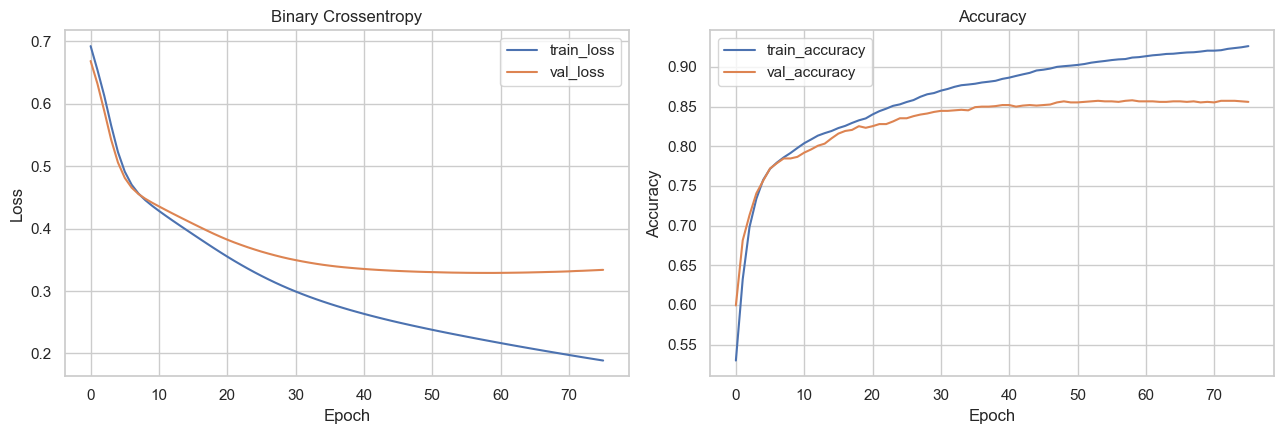

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Binary Crossentropy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()



## 10. Final Evaluation on the Test Set

Only now do we touch the test set. This is your final, unbiased checkpoint after all modeling decisions are complete. We evaluate with multiple metrics because each one captures a different behavior:

- **Accuracy**: the fraction of all predictions that were correct. This is easy to understand, but it can be misleading when classes are imbalanced.
- **Precision**: among all samples predicted as class `1`, how many were actually class `1`. High precision means fewer false positives.
- **Recall**: among all true class `1` samples, how many the model successfully found. High recall means fewer false negatives.
- **F1-score**: the harmonic mean of precision and recall. This is useful when you want a single number that rewards balance between the two.
- **ROC-AUC**: measures how well the model ranks positive samples above negative ones across many decision thresholds. A value near `1.0` is strong, while `0.5` is roughly random guessing.

The confusion matrix should be read cell-by-cell. Diagonal cells are correct predictions; off-diagonal cells are error types. Your interpretation should connect these errors back to design risk: is predicting “safe” when it is actually “high displacement” more costly than the reverse?

Because this is a structural-response setting, that trade-off matters. If missing a truly high-displacement case is more serious than issuing an occasional false alarm, then **recall** may matter more than **precision**. If false alarms are costly, then precision becomes more important.


Test metrics - MLP
Accuracy : 0.8547
Precision: 0.8590
Recall   : 0.8352
F1-score : 0.8469
ROC-AUC  : 0.9335

Test metrics - Logistic Regression baseline
Accuracy : 0.7760
Precision: 0.7644
Recall   : 0.7729
F1-score : 0.7686
ROC-AUC  : 0.8559

Detailed classification report (MLP):
              precision    recall  f1-score   support

           0     0.8509    0.8728    0.8617       778
           1     0.8590    0.8352    0.8469       722

    accuracy                         0.8547      1500
   macro avg     0.8549    0.8540    0.8543      1500
weighted avg     0.8548    0.8547    0.8546      1500



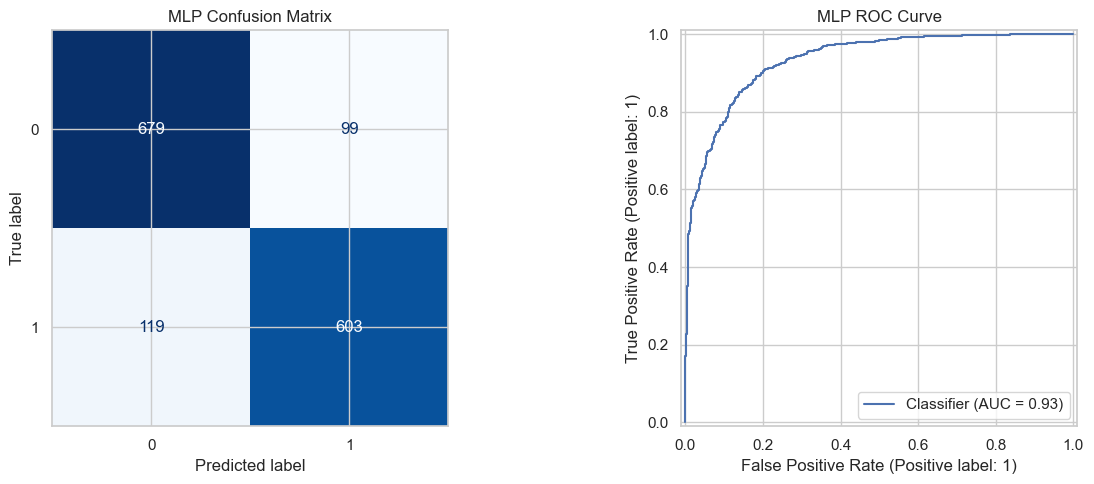

In [11]:

# MLP probabilities and class predictions
mlp_test_proba = model.predict(X_test, verbose=0).ravel()
mlp_test_pred = (mlp_test_proba >= 0.5).astype(int)

# Baseline predictions for direct comparison
baseline_test_pred = baseline.predict(X_test)
baseline_test_proba = baseline.predict_proba(X_test)[:, 1]

print("Test metrics - MLP")
print(f"Accuracy : {accuracy_score(y_test, mlp_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, mlp_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, mlp_test_pred):.4f}")
print(f"F1-score : {f1_score(y_test, mlp_test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, mlp_test_proba):.4f}")

print()
print("Test metrics - Logistic Regression baseline")
print(f"Accuracy : {accuracy_score(y_test, baseline_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, baseline_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, baseline_test_pred):.4f}")
print(f"F1-score : {f1_score(y_test, baseline_test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, baseline_test_proba):.4f}")

print()
print("Detailed classification report (MLP):")
print(classification_report(y_test, mlp_test_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    mlp_test_pred,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("MLP Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    mlp_test_proba,
    ax=axes[1],
)
axes[1].set_title("MLP ROC Curve")

plt.tight_layout()
plt.show()



## 11. Mini Exercises

1. Change `THRESHOLD` from `10` to `8` and `12`, rerun the notebook, and compare class balance plus metric changes. Explain why the same model architecture can behave differently under these threshold choices.
2. Increase the first hidden layer from `64` to `128` units and compare training/validation curves. Did performance improve on test data, or did overfitting increase?
3. Replace `StandardScaler` with `MinMaxScaler` and observe whether convergence speed or final metrics change.
4. Adjust the classification cutoff from `0.5` to `0.4` for test prediction and discuss how precision-recall trade-offs shift.
